# Espiral con scikit-learn

Este notebook genera un dataset tipo espiral y compara estos cinco clasificadores:

1. `GaussianNB`
2. `KNeighborsClassifier`
3. `DummyClassifier(strategy="prior")`
4. `QuadraticDiscriminantAnalysis` como una gaussiana por clase
5. Un clasificador bayesiano con `GaussianMixture` por clase

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from scipy.stats import multivariate_normal

try:
    import seaborn as sns
except ModuleNotFoundError:
    sns = None

from sklearn.base import BaseEstimator, ClassifierMixin
from sklearn.dummy import DummyClassifier
from sklearn.metrics import accuracy_score
from sklearn.mixture import GaussianMixture
from sklearn.naive_bayes import GaussianNB
from sklearn.neighbors import KNeighborsClassifier
from sklearn.discriminant_analysis import QuadraticDiscriminantAnalysis

In [2]:
def make_spiral_dataset(n_points_per_class=150, noise=0.12, rotations=2.1, random_state=42):
    rng = np.random.default_rng(random_state)
    theta = np.linspace(0.25, rotations * 2 * np.pi, n_points_per_class)
    radius = theta

    x0 = radius * np.cos(theta) + rng.normal(0, noise, n_points_per_class)
    y0 = radius * np.sin(theta) + rng.normal(0, noise, n_points_per_class)

    theta_1 = theta + np.pi
    x1 = radius * np.cos(theta_1) + rng.normal(0, noise, n_points_per_class)
    y1 = radius * np.sin(theta_1) + rng.normal(0, noise, n_points_per_class)

    X = np.vstack([
        np.column_stack([x0, y0]),
        np.column_stack([x1, y1])
    ])
    y = np.array([0] * n_points_per_class + [1] * n_points_per_class)
    X = X / np.max(np.abs(X))

    df = pd.DataFrame(X, columns=["x1", "x2"])
    df["label"] = y
    return df

In [3]:
df = make_spiral_dataset(n_points_per_class=140, noise=0.018, rotations=2.15, random_state=7)
X = df[["x1", "x2"]].to_numpy()
y = df["label"].to_numpy()
classes = np.unique(y)
colors = {0: "#1f77b4", 1: "#ff7f0e"}
class_means = df.groupby("label")[["x1", "x2"]].mean().reset_index()

df.head()

,x1,x2,label
0,0.019241,0.006483,0
1,0.026239,0.008511,0
2,0.031270,0.014863,0
3,0.035336,0.020620,0
4,0.039835,0.028720,0


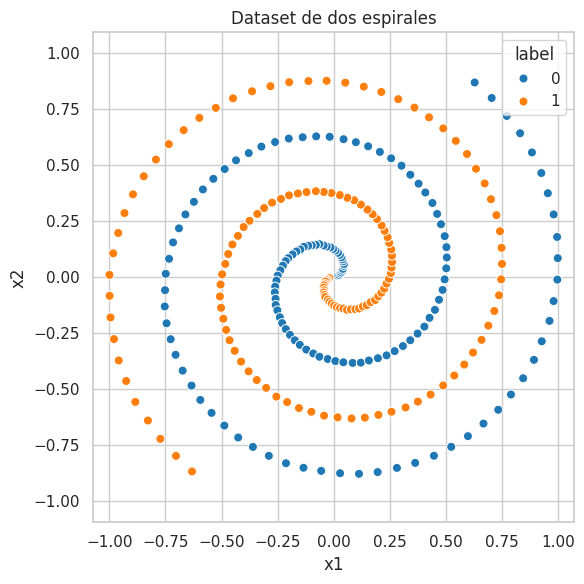

In [4]:
plt.figure(figsize=(6, 6))
if sns is not None:
    sns.set_theme(style="whitegrid")
    sns.scatterplot(data=df, x="x1", y="x2", hue="label", palette=[colors[0], colors[1]], s=42, edgecolor="white", linewidth=0.7)
else:
    for label, color in colors.items():
        subset = df[df["label"] == label]
        plt.scatter(subset["x1"], subset["x2"], s=42, c=color, edgecolors="white", linewidths=0.7, label=label)
    plt.grid(True, alpha=0.25)
plt.title("Dataset de dos espirales")
plt.xlabel("x1")
plt.ylabel("x2")
plt.axis("equal")
plt.legend(title="label")
plt.tight_layout()
plt.show()

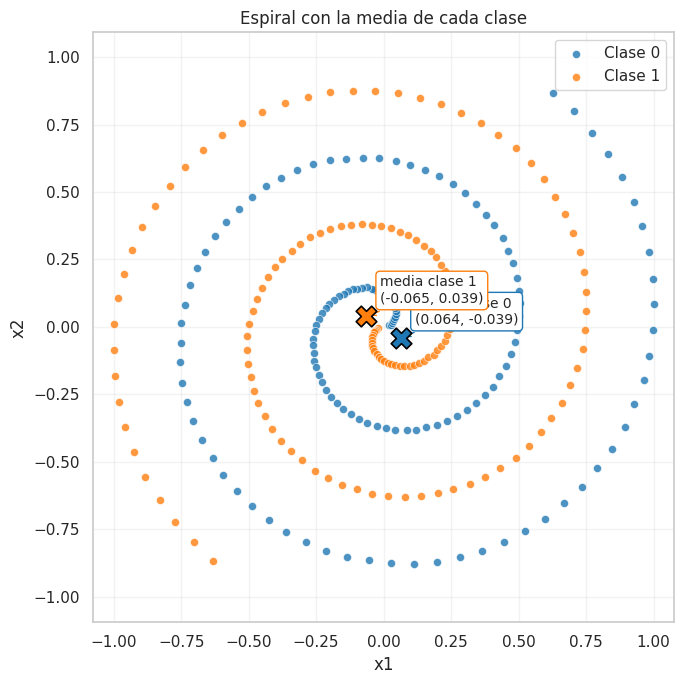

In [5]:
plt.figure(figsize=(7, 7))
for label, color in colors.items():
    subset = df[df["label"] == label]
    plt.scatter(subset["x1"], subset["x2"], s=34, c=color, alpha=0.8, edgecolors="white", linewidths=0.5, label=f"Clase {label}")

for _, row in class_means.iterrows():
    label = int(row["label"])
    plt.scatter(row["x1"], row["x2"], s=220, c=colors[label], marker="X", edgecolors="black", linewidths=1.2, zorder=5)
    plt.annotate(
        f"media clase {label}\n({row['x1']:.3f}, {row['x2']:.3f})",
        (row["x1"], row["x2"]),
        xytext=(10, 10),
        textcoords="offset points",
        fontsize=10,
        bbox=dict(boxstyle="round,pad=0.3", fc="white", ec=colors[label]),
        arrowprops=dict(arrowstyle="->", color=colors[label]),
    )

plt.title("Espiral con la media de cada clase")
plt.xlabel("x1")
plt.ylabel("x2")
plt.axis("equal")
plt.grid(True, alpha=0.25)
plt.legend()
plt.tight_layout()
plt.show()

## Clasificador bayesiano con mezcla de gaussianas

In [6]:
class GMMBayesClassifier(BaseEstimator, ClassifierMixin):
    def __init__(self, n_components=3, covariance_type="full", reg_covar=1e-4, random_state=10):
        self.n_components = n_components
        self.covariance_type = covariance_type
        self.reg_covar = reg_covar
        self.random_state = random_state

    def fit(self, X, y):
        self.classes_ = np.unique(y)
        self.priors_ = np.array([(y == cls).mean() for cls in self.classes_])
        self.models_ = {}
        for cls in self.classes_:
            gmm = GaussianMixture(
                n_components=self.n_components,
                covariance_type=self.covariance_type,
                reg_covar=self.reg_covar,
                random_state=self.random_state + int(cls),
            )
            gmm.fit(X[y == cls])
            self.models_[cls] = gmm
        return self

    def predict_log_proba(self, X):
        log_posts = []
        for i, cls in enumerate(self.classes_):
            log_density = self.models_[cls].score_samples(X)
            log_posts.append(np.log(self.priors_[i]) + log_density)
        log_posts = np.column_stack(log_posts)
        normalizer = np.logaddexp.reduce(log_posts, axis=1, keepdims=True)
        return log_posts - normalizer

    def predict(self, X):
        return self.classes_[np.argmax(self.predict_log_proba(X), axis=1)]

In [7]:
models = {
    "Naive Bayes": GaussianNB(var_smoothing=1e-4),
    "KNN (k=7)": KNeighborsClassifier(n_neighbors=7),
    "Solo priors": DummyClassifier(strategy="prior"),
    "1 gaussiana / clase": QuadraticDiscriminantAnalysis(reg_param=1e-3, store_covariance=True),
    "Mezcla de gaussianas": GMMBayesClassifier(n_components=3, reg_covar=1e-4, random_state=10),
}

for model in models.values():
    model.fit(X, y)

metrics_df = pd.DataFrame([
    {"modelo": name, "accuracy_entrenamiento": accuracy_score(y, model.predict(X))}
    for name, model in models.items()
]).sort_values("accuracy_entrenamiento", ascending=False).reset_index(drop=True)

metrics_df

,modelo,accuracy_entrenamiento
0,KNN (k=7),0.992857
1,1 gaussiana / clase,0.525000
2,Naive Bayes,0.517857
3,Solo priors,0.500000
4,Mezcla de gaussianas,0.492857


In [8]:
def make_grid(X, steps=320, padding=0.12):
    x_min, x_max = X[:, 0].min(), X[:, 0].max()
    y_min, y_max = X[:, 1].min(), X[:, 1].max()
    dx = (x_max - x_min) * padding
    dy = (y_max - y_min) * padding
    xx, yy = np.meshgrid(
        np.linspace(x_min - dx, x_max + dx, steps),
        np.linspace(y_min - dy, y_max + dy, steps),
    )
    grid = np.column_stack([xx.ravel(), yy.ravel()])
    return xx, yy, grid

xx, yy, grid = make_grid(X)

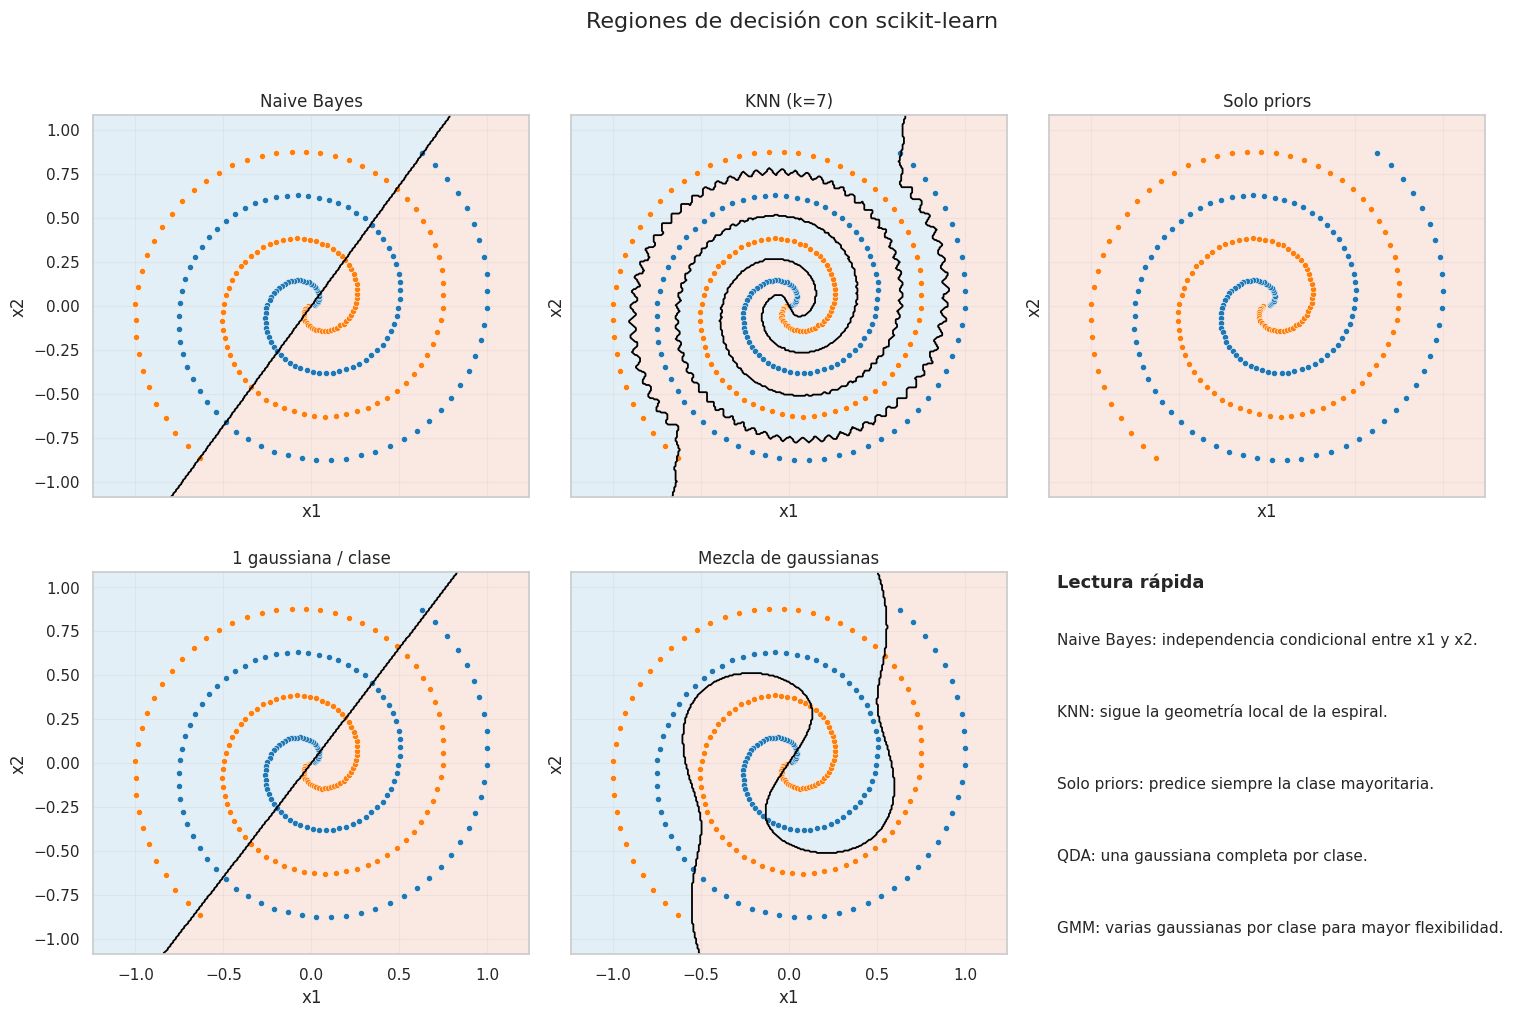

In [9]:
def plot_decision_regions(ax, title, model, X, y, xx, yy, grid):
    Z = model.predict(grid).reshape(xx.shape)
    ax.contourf(xx, yy, Z, levels=np.linspace(-0.5, 1.5, 3), cmap=plt.cm.RdBu, alpha=0.18)
    ax.contour(xx, yy, Z, levels=[0.5], colors="black", linewidths=1.3)
    for cls in np.unique(y):
        subset = X[y == cls]
        ax.scatter(subset[:, 0], subset[:, 1], s=20, c=colors[int(cls)], edgecolors="white", linewidths=0.4)
    ax.set_title(title)
    ax.set_xlabel("x1")
    ax.set_ylabel("x2")
    ax.set_aspect("equal", adjustable="box")
    ax.grid(True, alpha=0.2)

fig, axes = plt.subplots(2, 3, figsize=(16, 10), sharex=True, sharey=True)
axes = axes.ravel()

for ax, (name, model) in zip(axes, models.items()):
    plot_decision_regions(ax, name, model, X, y, xx, yy, grid)

axes[-1].axis("off")
axes[-1].text(0.02, 0.95, "Lectura rápida", transform=axes[-1].transAxes, fontsize=13, fontweight="bold", va="top")
axes[-1].text(0.02, 0.78, "Naive Bayes: independencia condicional entre x1 y x2.", transform=axes[-1].transAxes, fontsize=11)
axes[-1].text(0.02, 0.61, "KNN: sigue la geometría local de la espiral.", transform=axes[-1].transAxes, fontsize=11)
axes[-1].text(0.02, 0.44, "Solo priors: predice siempre la clase mayoritaria.", transform=axes[-1].transAxes, fontsize=11)
axes[-1].text(0.02, 0.27, "QDA: una gaussiana completa por clase.", transform=axes[-1].transAxes, fontsize=11)
axes[-1].text(0.02, 0.10, "GMM: varias gaussianas por clase para mayor flexibilidad.", transform=axes[-1].transAxes, fontsize=11)

fig.suptitle("Regiones de decisión con scikit-learn", fontsize=16, y=1.02)
plt.tight_layout()
plt.show()

## Cómo se forma la frontera en los modelos gaussianos

La frontera negra aparece donde los log-posteriors de ambas clases son iguales:

$$\log p(C_0) + \log p(x \mid C_0) = \log p(C_1) + \log p(x \mid C_1)$$

In [10]:
def qda_covariance_matrix(model, class_index):
    if hasattr(model, "covariance_"):
        return model.covariance_[class_index]
    rotation = model.rotations_[class_index]
    scaling = model.scalings_[class_index]
    return rotation @ np.diag(scaling) @ rotation.T

def plot_gaussian_boundary(ax, X, y, xx, yy, grid, model, title):
    log_post = model.predict_log_proba(grid)
    diff = (log_post[:, 1] - log_post[:, 0]).reshape(xx.shape)
    pred = (diff >= 0).astype(int)
    ax.contourf(xx, yy, pred, levels=np.linspace(-0.5, 1.5, 3), cmap=plt.cm.RdBu, alpha=0.15)
    ax.contour(xx, yy, diff, levels=[0], colors="black", linewidths=1.6)

    for cls in np.unique(y):
        subset = X[y == cls]
        ax.scatter(subset[:, 0], subset[:, 1], s=18, c=colors[int(cls)], edgecolors="white", linewidths=0.4)

    if title == "Naive Bayes":
        for idx, cls in enumerate(model.classes_):
            mean = model.theta_[idx]
            var = model.var_[idx]
            density = multivariate_normal(mean=mean, cov=np.diag(var)).pdf(grid).reshape(xx.shape)
            ax.contour(xx, yy, density, levels=5, colors=colors[int(cls)], alpha=0.7)
            ax.scatter(mean[0], mean[1], c=colors[int(cls)], marker="X", s=180, edgecolors="black", linewidths=1.1)
    elif title == "1 gaussiana / clase":
        for idx, cls in enumerate(model.classes_):
            mean = model.means_[idx]
            cov = qda_covariance_matrix(model, idx)
            density = multivariate_normal(mean=mean, cov=cov).pdf(grid).reshape(xx.shape)
            ax.contour(xx, yy, density, levels=5, colors=colors[int(cls)], alpha=0.7)
            ax.scatter(mean[0], mean[1], c=colors[int(cls)], marker="X", s=180, edgecolors="black", linewidths=1.1)
    else:
        for cls in model.classes_:
            gmm = model.models_[cls]
            density = np.exp(gmm.score_samples(grid)).reshape(xx.shape)
            ax.contour(xx, yy, density, levels=5, colors=colors[int(cls)], alpha=0.7)
            for mean in gmm.means_:
                ax.scatter(mean[0], mean[1], c=colors[int(cls)], marker="X", s=110, edgecolors="black", linewidths=0.8)

    ax.set_title(title)
    ax.set_xlabel("x1")
    ax.set_ylabel("x2")
    ax.set_aspect("equal", adjustable="box")
    ax.grid(True, alpha=0.2)

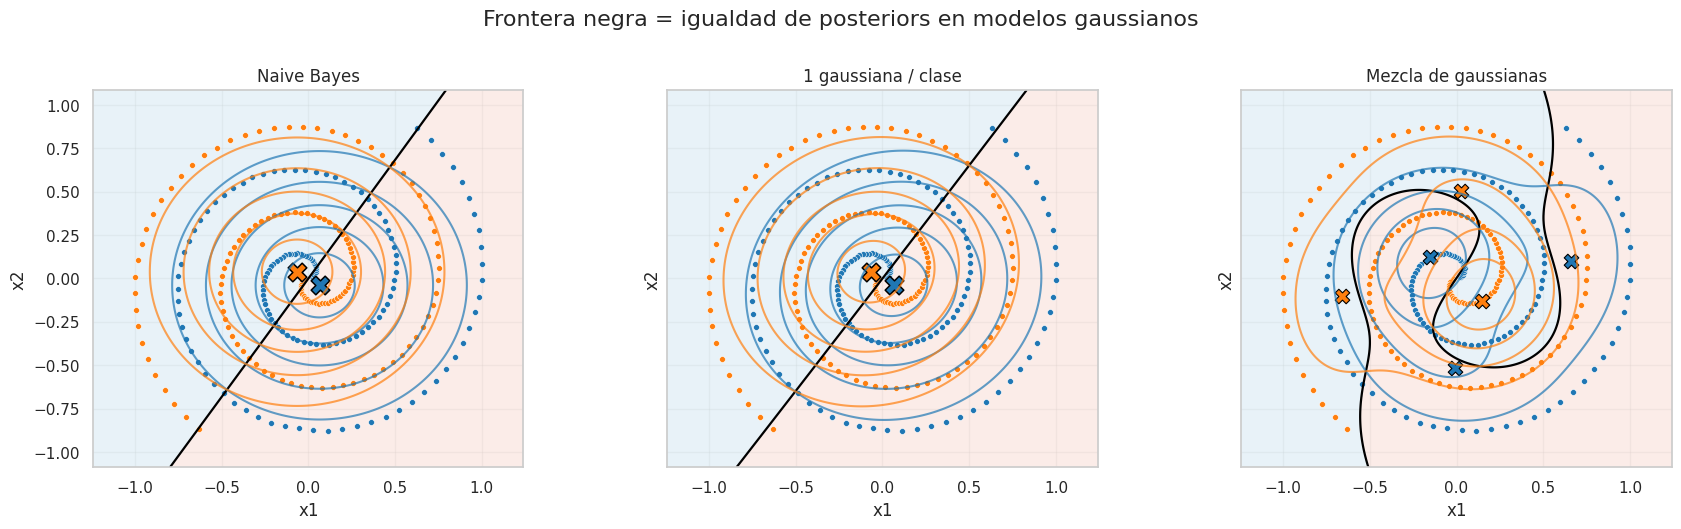

In [11]:
fig, axes = plt.subplots(1, 3, figsize=(18, 5), sharex=True, sharey=True)

plot_gaussian_boundary(axes[0], X, y, xx, yy, grid, models["Naive Bayes"], "Naive Bayes")
plot_gaussian_boundary(axes[1], X, y, xx, yy, grid, models["1 gaussiana / clase"], "1 gaussiana / clase")
plot_gaussian_boundary(axes[2], X, y, xx, yy, grid, models["Mezcla de gaussianas"], "Mezcla de gaussianas")

fig.suptitle("Frontera negra = igualdad de posteriors en modelos gaussianos", fontsize=16, y=1.03)
plt.tight_layout()
plt.show()

In [12]:
df.to_csv("espiral_dataset.csv", index=False)
print("Archivo guardado como espiral_dataset.csv")

Archivo guardado como espiral_dataset.csv
